In [ ]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project         : Handwritten Digit Classification (Digits 8×8)
Algorithm       : Bidirectional Recurrent Neural Network (BiRNN) – completely from scratch

Description     : Full manual implementation of a Bidirectional Vanilla RNN 
                  without using any high-level recurrent layers.

                  Implemented components from scratch:
                  - Forward RNN and Backward RNN
                  - Forward propagation through time in both directions
                  - Backpropagation Through Time (BPTT)
                  - Softmax output for multi-class classification

                  Part of the comprehensive Deep Learning course.
============================================================================
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits

c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#%% load dataset 
ds= load_digits()
data= ds['data']
target= ds['target']

In [3]:
Xtrain,Xtest,y_train,y_test=train_test_split(data,target,
                                                 train_size=0.7,
                                                 shuffle=True)

In [4]:
# standardize
scaler= prep.StandardScaler()
Xtrain= scaler.fit_transform(Xtrain)
Xtest= scaler.transform(Xtest)

In [5]:
#%% convert to tensor
Xtrain= torch.from_numpy(Xtrain).type(torch.float32).unsqueeze(2)
y_train= torch.from_numpy(y_train).type(torch.float32)
y_train_onhot=(y_train.reshape(-1,1)==
               torch.arange(10).reshape(1,-1)).type(torch.float32)



Xtest= torch.from_numpy(Xtest).type(torch.float32).unsqueeze(2)
y_test= torch.from_numpy(y_test).type(torch.float32)
y_test_onhot=(y_test.reshape(-1,1)==torch.arange(10).reshape(1,-1)).type(torch.float32)

In [6]:
class Customdataset(Dataset):
    def __init__(self,data,label):
        super().__init__()
        self.data= data
        self.label= label
    def __len__(self):
        return self.label.shape[0]
    def __getitem__(self, index):
        x= self.data[index]
        y= self.label[index]
        
        x= x.reshape(8,8)
        # x= x.permute(1,0)
        return x,y
        

In [7]:
#% build data loader 
# ds= TensorDataset(Xtrain,y_train_onhot)
ds= Customdataset(Xtrain,y_train_onhot)
train_loader= DataLoader(ds,batch_size=4,
                         shuffle=False,
                         drop_last=True)

In [8]:
# y_train_onhot

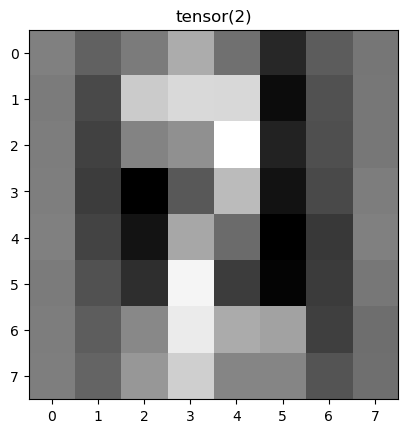

In [9]:
x,y = ds[1000]
plt.imshow(x,cmap='gray')
plt.title(torch.argmax(y))
plt.show()

In [10]:
class RNN():
     def __init__(self,n_features,
                  n_hidden1,# RNN1
                  n_out,# linear 2
                  lr=0.001,wrate=1):
          self.wx= torch.randn(n_hidden1,n_features)*wrate
          self.bx= torch.randn(n_hidden1,1)*wrate
          
          self.wh= torch.randn(n_hidden1,n_hidden1)*wrate
          
          
          self.wc= torch.randn(n_hidden1,n_features)*wrate
          self.bc= torch.randn(n_hidden1,1)*wrate
          
          self.whc= torch.randn(n_hidden1,n_hidden1)*wrate

          self.wo= torch.randn(n_out,n_hidden1*2)*wrate
          self.bo= torch.randn(n_out,1)*wrate
          
          self.lr=lr
          self.n_out= n_out
          self.n_hidden1= n_hidden1
          self.n_features= n_features
          
          self.dwx= torch.zeros_like(self.wx)
          self.dbx= torch.zeros_like(self.bx)
          self.dwh= torch.zeros_like(self.wh)
          
          self.dwc= torch.zeros_like(self.wc)
          self.dbc= torch.zeros_like(self.bc)
          self.dwhc= torch.zeros_like(self.whc)
          
          self.dwo= torch.zeros_like(self.wo)
          self.dbo= torch.zeros_like(self.bo)

          
     def __call__(self,x,h0=None,c0=None):
          yos,hts,hps,cts,cps= self.forward(x,h0,c0)
          return yos,hts,hps,cts,cps
              
     def forward(self,x,h0=None,c0=None):
          wx,bx,wh,wc,bc,whc= self.wx,self.bx,self.wh,self.wc,self.bc,self.whc,
          wo,bo=self.wo,self.bo  
          batch_size,T,_= x.size()
          n_hidden1= self.n_hidden1
          if h0==None:
               h_prev= torch.zeros(n_hidden1,batch_size)
               c_prev= torch.zeros(n_hidden1,batch_size)
          else:
               h_prev= h0 
               c_prev= c0   
          # self.input=x
          yos=[]
          hts=[]
          hps=[]  
          cts=[]  
          cps=[] 
          for t in range(T):
               xt_frist= x[:,t,:].T # n_f x b_s
               xt_last= x[:,T-t-1,:].T # n_f x b_s
               vt=( wx @ xt_frist) + (wh @ h_prev) + bx # n_hid x b_s
               ht= torch.tanh(vt) # n_hid x b_s
               
               vc_t= ( wc @ xt_last) + (whc @ c_prev) + bc # n_hid x b_s
               ct= torch.tanh(vc_t)

               hts.append(ht)
               hps.append(h_prev)
               cts.append(ct)
               cps.append(c_prev)
               h_prev= ht
               c_prev= ct
          
          hc_concat=torch.concat((hts[-1],cts[-1]),dim=0) # (n_hid*2) x b_s 
          vo_t= (wo@hc_concat)+bo # n_o x b_s
          yt= torch.softmax(vo_t,dim=0)         
          yos.append(yt)
               
          return yos,hts,hps,cts,cps
       
                
     def backward(self,x,y_true,y_pred,hts,hps,cts,cps):
          wx,bx,wh,wc,bc,whc= self.wx,self.bx,self.wh,self.wc,self.bc,self.whc,
          wo,bo=self.wo,self.bo  
          batch_size,T,_= x.size()
          n_hidden1= self.n_hidden1
          
          yot= y_pred[-1]
          dt= y_true.T #  n_out x b_s 
          et= (dt - yot) # n_out x b_s
          delta_o=  et # n_out x b_s 
          
          hc_concat=torch.concat((hts[-1],cts[-1]),dim=0).T
          self.dwo= delta_o@hc_concat  # n_out x n_hid
          self.dbo= torch.sum(delta_o,dim=1,keepdim=True)# n_out x 1

          dh_next= torch.zeros(batch_size,n_hidden1)
          dc_next= torch.zeros(batch_size,n_hidden1)
          
          
          delta_from_out= (delta_o.T@wo) # b_s x n_hid
          
          dh_out= delta_from_out[:,:n_hidden1]
          dc_out= delta_from_out[:,n_hidden1:]
          for t in reversed(range(T)):
               xt_first= x[:,t,:] #  b_s * n_f
               xt_last=  x[:,T-t-1,:] #  b_s * n_f
               ht= hts[t].T # (n_hid x b_s).T= (b_s x n_hid)
               h_prev= hps[t].T# (n_hid x b_s).T= (b_s x n_hid)
              
               ct= cts[t].T # (n_hid x b_s).T= (b_s x n_hid)
               c_prev= cps[t].T# (n_hid x b_s).T= (b_s x n_hid)
               
               # dc= ((dc_out + dc_next@whc)*gdc).T #  n_hid x b_s
               if t==T-1:
                    dc= dc_out
                    dh= dh_out
                    # print('hello')
               else:
                    dc= dc_next
                    dh= dh_next
                    # print('hi')
                    
               gdc= self.g_tanh(ct)# (b_s x n_hid)
               dzc= (dc*gdc).T #  n_hid x b_s
               self.dwc+= (dzc@ xt_last)# (n_hid x b_s)x (b_s * n_f)= n_hid x n_f
               self.dbc+= torch.sum(dzc,dim=1,keepdim=True)# n_hid x 1
               
               self.dwhc+= (dzc @ c_prev)#(n_hid x b_s)x (b_s x n_hid)= n_hid x n_hid

               gdh= self.g_tanh(ht)# (b_s x n_hid)
               # dh= ((dh_out + dh_next@wh)*gdh).T #  n_hid x b_s
               dzh= (dh*gdh).T #  n_hid x b_s
               self.dwx+= (dzh@ xt_first)# (n_hid x b_s)x (b_s * n_f)= n_hid x n_f
               self.dbx+= torch.sum(dzh,dim=1,keepdim=True)# n_hid x 1
               
               self.dwh+= (dzh @ h_prev)#(n_hid x b_s)x (b_s x n_hid)= n_hid x n_hid
               
               dh_next= dzh.T@wh#   b_s*n_hid x
               dc_next= dzc.T@whc #   b_s*n_hid x
          
          # self.dwx/=(batch_size)
          # self.dbx/=(batch_size)
          # self.dwh/=(batch_size)
          
          # self.dwc/=(batch_size)
          # self.dbc/=(batch_size)
          # self.dwhc/=(batch_size)
          
          # self.dwo/=(batch_size*T)
          # self.dbo/=(batch_size*T)
     
     def zero_grad(self):
          self.dwx.zero_()
          self.dbx.zero_()
          self.dwh.zero_()
          
          self.dwc.zero_()
          self.dbc.zero_()
          self.dwhc.zero_()
          
          self.dwo.zero_()
          self.dbo.zero_()
     
     def step(self):
          self.wx+=self.lr*self.dwx
          self.bx+=self.lr*self.dbx
          self.wh+=self.lr*self.dwh
          
          self.wc+=self.lr*self.dwc
          self.bc+=self.lr*self.dbc
          self.whc+=self.lr*self.dwhc
          
          self.wo+=self.lr*self.dwo
          self.bo+=self.lr*self.dbo
          
     def mse(self,y_true,y_pred):
          y_true= y_true.T
          e= y_true-y_pred
          return torch.mean(e**2)
     
     def g_tanh(self,y):
          return (1-y**2)
     
     def g_sigmoid(self,y):
          return y*(1-y)
     
     def g_relu(self,y):
          yhat= (y>0).type(torch.float32)
          return yhat
     
     def g_linear(self,y):
          return torch.ones(y.size())
     
     def clipping(self,grad_clip_val):
          params= [self.dwx,self.dbx,self.dwh,self.dwc,
                   self.dbc,self.dwhc,self.dwo,self.dbo  ]
          norm = torch.sqrt(sum(torch.sum((p ** 2)) for p in params))
          if norm > grad_clip_val:
               for param in params:
                    param.mul_(grad_clip_val / norm) 
     

def xavier_init(shape):
    fan_in, fan_out = shape[1], shape[0]
    limit = torch.sqrt(torch.tensor(6.0 / (fan_in + fan_out)))
    return torch.empty(shape).uniform_(-limit, limit)

def orthogonal_init(shape):
    # shape = (n_hidden, n_hidden)
    W = torch.randn(shape)
    q, r = torch.linalg.qr(W)
    # Ensure determinant is positive (for orthogonal)
    if torch.det(q) < 0:
        q[:, 0] = -q[:, 0]
    return q



In [11]:
#%% train Neural Network
torch.manual_seed(1)
lr=0.01
n_out= 10
n_hid1= 128
n_features=8
mdl= RNN(n_features, 
         n_hid1,
         n_out,
         lr,wrate=0.1)

In [12]:
mse=[]
epoch=20
h0=None
c0=None
mdl.clip=50
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          # farward pass
          ypred,hts,hps,cts,cps= mdl(xbatch,h0,c0)
          h0= hts[-1]
          c0= cts[-1]
          mdl.zero_grad()
          mdl.backward(xbatch,ybatch,ypred,hts,hps,cts,cps) 
          # mdl.clipping(10)
          mdl.step()
          er.append(mdl.mse(ybatch,ypred[-1])) 
          # print(er[i])
          

     loss= torch.mean(torch.tensor(er))
     mse.append(loss)
     print(f'MSE({iter}): {mse[iter]:.8f}')

mse=torch.tensor(mse)

MSE(0): 0.01863718
MSE(1): 0.00369750
MSE(2): 0.00066091
MSE(3): 0.00014149
MSE(4): 0.00006207
MSE(5): 0.00003503
MSE(6): 0.00002239
MSE(7): 0.00001545
MSE(8): 0.00001125
MSE(9): 0.00000852
MSE(10): 0.00000666
MSE(11): 0.00000534
MSE(12): 0.00000437
MSE(13): 0.00000363
MSE(14): 0.00000306
MSE(15): 0.00000262
MSE(16): 0.00000226
MSE(17): 0.00000196
MSE(18): 0.00000172
MSE(19): 0.00000152


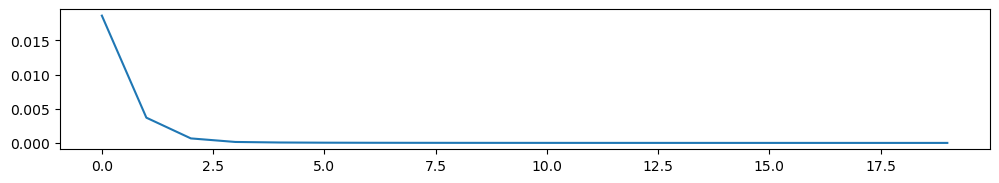

In [13]:
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

In [14]:
#%% test trained Neural Network
ds_test= Customdataset(Xtest,y_test)
ypred=[]
h0=None
for i in range(Xtest.size(0)):
    xt= ds_test[i][0]
    xt= xt.unsqueeze(0)
    yp= mdl(xt)[0]
    yp= torch.argmax(yp[-1].T,dim=1)
    ypred.append(yp)

ypred= np.array(ypred)

In [15]:
ypred=ypred.flatten()
d_test= y_test.flatten()

print(ypred.shape,d_test.shape,Xtest.shape,yp[-1].shape,Xtest[i].shape)

(540,) torch.Size([540]) torch.Size([540, 64, 1]) torch.Size([]) torch.Size([64, 1])


Total accuracy:95.000%
accuracy0:100.000%
accuracy1:100.000%
accuracy2:100.000%
accuracy3:90.566%
accuracy4:90.909%
accuracy5:96.364%
accuracy6:97.778%
accuracy7:100.000%
accuracy8:87.755%
accuracy9:89.474%


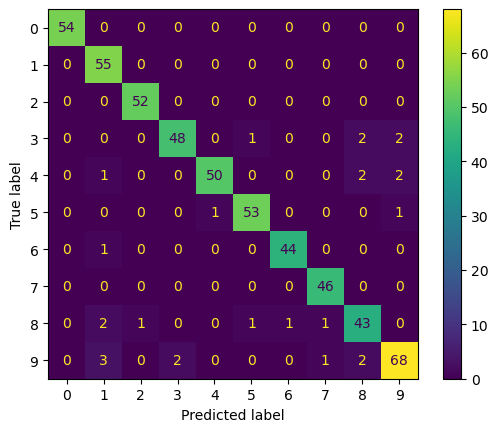

In [16]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
#%% test trained Neural Network
C= confusion_matrix(d_test,ypred)
# print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()